In [ ]:
# Imports
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy.interpolate import PchipInterpolator
from scipy.interpolate import make_interp_spline

In [150]:
current_directory = Path.cwd().parent
compiled_file_name = Path.joinpath(current_directory, "final_cleaned_compiled.csv")
points_of_interest_file_name = Path.joinpath(current_directory, "points_of_interest.json")
RC_values_file_name = Path.joinpath(current_directory, "RC_values.csv")
ocv_soc_dict_file_name = Path.joinpath(current_directory, "ocv_soc_dict.json")


In [ ]:
points_of_interest = json.load(open(points_of_interest_file_name, 'r'))

In [ ]:
compiled_df = pd.read_csv(compiled_file_name)

In [128]:
compiled_df['Charge Change'] = 0.0
for index, row in compiled_df.iterrows():
    if index % 1000 == 0:
        print(f"Processing row {index}/{len(compiled_df)}", end='\r')
        
    if index == 0:
        continue
    
    # Trapezoidal integration for charge change
    delta_time = (row['Translated Time'] - compiled_df.at[index-1, 'Translated Time']) / 1000  # Convert ms to seconds
    current_c = (row['Calibrated Current 1'] + row['Calibrated Current 2']) / 2
    previous_current_c = (compiled_df.at[index-1, 'Calibrated Current 1'] + compiled_df.at[index-1, 'Calibrated Current 2']) / 2
    average_current = (current_c + previous_current_c) / 2
    charge_change = average_current * delta_time
    compiled_df.at[index, 'Charge Change'] = charge_change

total_Ah = compiled_df['Charge Change'].sum()/3600

In [129]:
compiled_df['SoC'] = 100.0
# SoC from discharge curve
total_charge = total_Ah * 3600  # Convert Ah to Coulombs
accumulated_charge = 0.0
for index, row in compiled_df.iterrows():
    if index % 1000 == 0:
        print(f"Calculating SoC for row {index}/{len(compiled_df)}", end='\r')
    
    compiled_df.at[index, 'SoC'] = (total_charge - accumulated_charge) / total_charge * 100
    accumulated_charge += row['Charge Change']

In [58]:
compiled_df.head(10)

,Translated Time,Translated Time (minutes),ADS Reading 1 (Smoothed and Offset),Calibrated Current 1,ADS Reading 2 (Smoothed and Offset),Calibrated Current 2,ADS Reading 3 (Smoothed),Calibrated Voltage,Charge Change,SoC
0,1000,0.016667,2.863429,0.008564,4.816303,0.014406,25542.0,58.202529,0.000000,100.000000
1,1032,0.017200,-1.136571,-0.003399,4.816303,0.014406,25541.5,58.202529,0.000272,100.000000
2,1064,0.017733,1.863429,0.005573,4.816303,0.014406,25541.0,58.197972,0.000248,100.000000
3,1095,0.018250,1.863429,0.005573,4.816303,0.014406,25541.0,58.200251,0.000310,100.000000
4,1126,0.018767,-3.136571,-0.009381,4.816303,0.014406,25541.0,58.200251,0.000194,100.000000
5,1157,0.019283,-4.136571,-0.012372,4.816303,0.014406,25541.0,58.200251,0.000055,100.000000
6,1189,0.019817,-3.136571,-0.009381,4.816303,0.014406,25541.0,58.200251,0.000056,100.000000
7,1220,0.020333,-3.136571,-0.009381,4.816303,0.014406,25541.0,58.200251,0.000078,100.000000
8,1251,0.020850,2.863429,0.008564,4.816303,0.014406,25541.0,58.200251,0.000217,100.000000
9,1283,0.021383,3.863429,0.011555,4.816303,0.014406,25541.0,58.200251,0.000391,99.999999


In [132]:
before_close = points_of_interest['before_close']
before_open = points_of_interest['before_open']
before_close['SoC'] = []
before_open['SoC'] = []
for index in before_close['index']:
    before_close['SoC'].append(compiled_df.at[index, 'SoC'])

for index in before_open['index']:
    before_open['SoC'].append(compiled_df.at[index, 'SoC'])
    
print(f"Before Close: {json.dumps(before_close)}")
print(f"Before Open: {json.dumps(before_open)}")
print(len(before_close['SoC']), len(before_close['voltage']))
print(len(before_open['SoC']), len(before_open['voltage']))

Before Close: {"index": [20, 32058, 94622, 157518, 205837, 246077, 279342, 318421, 376987, 423816, 467777, 512840, 554289, 612265], "time": [0.021642500000000002, 27.488850833333334, 74.68294416666666, 120.50311833333335, 162.82888416666665, 194.227285, 221.01904833333333, 253.10861833333334, 297.748795, 336.9438641666667, 381.58887583333336, 426.1225583333333, 466.5861616666667, 509.38955999999996], "voltage": [58.20104818239796, 57.050191262755106, 56.33297075892857, 55.32122841198981, 54.101099043367356, 53.12296750637756, 52.38250427295918, 51.800866358418375, 51.3479749362245, 50.83982506377553, 50.25362975127552, 49.44298258928572, 49.103114636479596, 46.726545535714294], "SoC": [99.99999746712042, 92.16918593733034, 84.75215632661926, 76.2001284235398, 68.52187943413767, 61.020490988057944, 54.5289925238714, 47.5059452716566, 39.579946532258745, 32.12359299329603, 24.45050798955372, 17.41190154985891, 10.33504799977742, 3.389258301516698]}
Before Open: {"index": [12936, 46343, 1

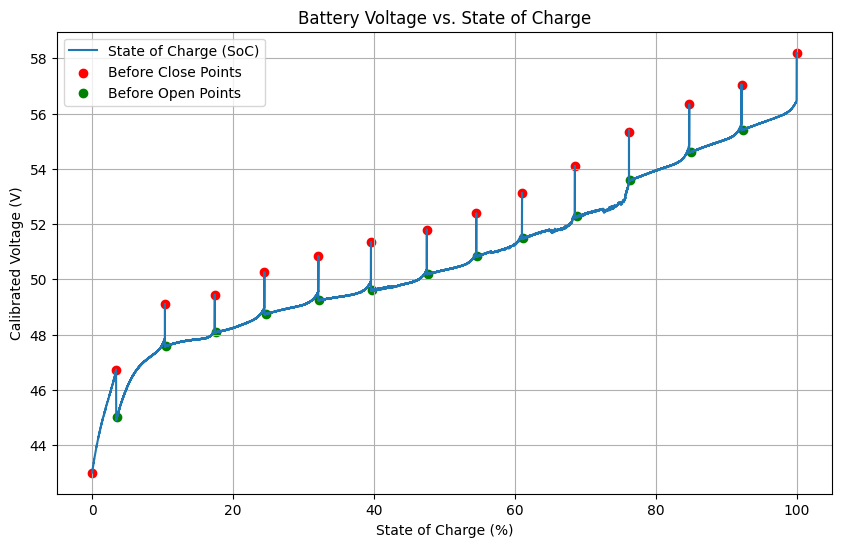

In [137]:
plt.figure(figsize=(10, 6))
plt.plot(compiled_df['SoC'], compiled_df['Calibrated Voltage'], label='State of Charge (SoC)')
plt.scatter(before_close['SoC'], before_close['voltage'], color='red', label='Before Close Points')
plt.scatter(before_open['SoC'], before_open['voltage'], color='green', label='Before Open Points')
plt.xlabel('State of Charge (%)')
plt.ylabel('Calibrated Voltage (V)')
plt.title('Battery Voltage vs. State of Charge')
plt.legend()
plt.grid(True)
plt.show()

In [134]:
last_point = compiled_df.iloc[-1]

if before_close['index'][-1] != len(compiled_df) - 1:
    before_close['SoC'].append(last_point['SoC'])
    before_close['voltage'].append(last_point['Calibrated Voltage'])
    before_close['index'].append(len(compiled_df) - 1)
    
    print(f"Added last point to before_close: SoC={last_point['SoC']}, Voltage={last_point['Calibrated Voltage']}, Index={len(compiled_df) - 1}")

Added last point to before_close: SoC=0.00032281073317373573, Voltage=42.99677104591837, Index=617919


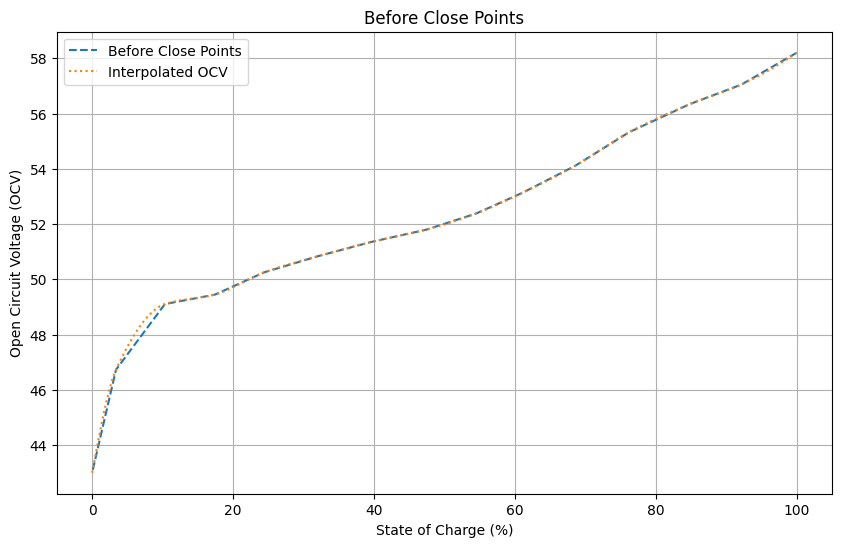

In [138]:
soc = np.flip(np.array(before_close['SoC'].copy()))
ocv = np.flip(np.array(before_close['voltage'].copy()))
soc_smooth = np.linspace(0, 100, 500)

piecewise_cubic_interp = PchipInterpolator(soc, ocv)
piecewise_cubic_spline_ocv_smooth = piecewise_cubic_interp(soc_smooth)

cubic_spline_interp = make_interp_spline(soc, ocv)
cubic_spline_ocv_smooth = cubic_spline_interp(soc_smooth)

plt.figure(figsize=(10, 6))
plt.plot(before_close['SoC'], before_close['voltage'], label='Before Close Points', linestyle='--')
plt.plot(soc_smooth, piecewise_cubic_spline_ocv_smooth, label='Interpolated OCV', linestyle=':')
#plt.plot(soc_smooth, cubic_spline_ocv_smooth, label='Cubic Spline OCV', linestyle=':')

plt.xlabel('State of Charge (%)')
plt.ylabel('Open Circuit Voltage (OCV)')
plt.title('Before Close Points')
plt.legend()
plt.grid(True)
plt.show()

In [141]:
# Piecewise Function

print("Function: f(x) = c0*(x-x_i)^3 + c1*(x-x_i)^2 + c2*(x-x_i) + c3 for x in [x_i, x_{i+1}]")
knots = piecewise_cubic_interp.x
coef = piecewise_cubic_interp.c
intervals = len(coef[0])
print(f"Total number of intervals: {intervals}")
for i in range(intervals):
    print(f"Interval {i}:\tx in [{knots[i]}, {knots[i+1]}]")
    print(f"\t\tCoefficients: c0={coef[0][i]}, c1={coef[1][i]}, c2={coef[2][i]}, c3={coef[3][i]}")

Function: f(x) = c0*(x-x_i)^3 + c1*(x-x_i)^2 + c2*(x-x_i) + c3 for x in [x_i, x_{i+1}]
Total number of intervals: 14
Interval 0:	x in [0.00032281073317373573, 3.389258301516698]
		Coefficients: c0=-0.025803397052302203, c1=0.014060991662691591, c2=1.3492712813949168, c3=42.99677104591837
Interval 1:	x in [3.389258301516698, 10.33504799977742]
		Coefficients: c0=-0.0009195938746827392, c1=-0.024331757566416104, c2=0.5555278214274972, c3=46.726545535714294
Interval 2:	x in [10.33504799977742, 17.41190154985891]
		Coefficients: c0=0.0011218878964948332, c1=-0.01308315484062101, c2=0.08442663374987007, c3=49.103114636479596
Interval 3:	x in [17.41190154985891, 24.45050798955372]
		Coefficients: c0=-0.0014211212161120243, c1=0.016731511617731395, c2=0.06781017700064249, c3=49.44298258928572
Interval 4:	x in [24.45050798955372, 32.12359299329603]
		Coefficients: c0=0.00019283515306622138, c1=-0.0035298520715033622, c2=0.09212774862576309, c3=50.25362975127552
Interval 5:	x in [32.12359299329

In [143]:
knots = piecewise_cubic_interp.x
coef = piecewise_cubic_interp.c
intervals = len(coef[0])
print(f"Total number of intervals: {intervals}")
for i in range(intervals):
    print(f"Interval {i}: f(x) = {coef[0][i]} * (x-{knots[i]})**3 + {coef[1][i]} * (x-{knots[i]})**2 + {coef[2][i]} * (x-{knots[i]}) + {coef[3][i]} \n\tfor x in [{knots[i]}, {knots[i+1]}]")
    


Total number of intervals: 14
Interval 0: f(x) = -0.025803397052302203 * (x-0.00032281073317373573)**3 + 0.014060991662691591 * (x-0.00032281073317373573)**2 + 1.3492712813949168 * (x-0.00032281073317373573) + 42.99677104591837 
	for x in [0.00032281073317373573, 3.389258301516698]
Interval 1: f(x) = -0.0009195938746827392 * (x-3.389258301516698)**3 + -0.024331757566416104 * (x-3.389258301516698)**2 + 0.5555278214274972 * (x-3.389258301516698) + 46.726545535714294 
	for x in [3.389258301516698, 10.33504799977742]
Interval 2: f(x) = 0.0011218878964948332 * (x-10.33504799977742)**3 + -0.01308315484062101 * (x-10.33504799977742)**2 + 0.08442663374987007 * (x-10.33504799977742) + 49.103114636479596 
	for x in [10.33504799977742, 17.41190154985891]
Interval 3: f(x) = -0.0014211212161120243 * (x-17.41190154985891)**3 + 0.016731511617731395 * (x-17.41190154985891)**2 + 0.06781017700064249 * (x-17.41190154985891) + 49.44298258928572 
	for x in [17.41190154985891, 24.45050798955372]
Interval 4:

In [ ]:
# 2 options: Reverse each interval function to get SoC from OCV or a dictionary of OCV to SoC values for each point ~1000 interval.

In [ ]:
# Option 2: Faster O(1), but takes ~3000kb of data for 3 dp precision. 
# Not suitable for microcontroller but can be used for RPi

factor = 3 # 3 dp
array_interval = factor + 2 # Additional 2 for 0 - 100% SoC
ocv_soc_dict = {}
ocv_intervals = np.linspace(0, 100, 10**array_interval + 1)
for ocv_value in ocv_intervals:
    soc_value = piecewise_cubic_interp(ocv_value)
    ocv_soc_dict[round(ocv_value, factor+2)] = soc_value.item()

json.dump(ocv_soc_dict, open(ocv_soc_dict_file_name, 'w'), indent=2)
print(f"Saved OCV to SoC dictionary with {len(ocv_soc_dict)} entries to {ocv_soc_dict_file_name}")
print(f"To use, get the ceiling of voltage reading to {factor} decimal places and look up corresponding SoC value in the dictionary.")


Saved OCV to SoC dictionary with 100001 entries to c:\Users\Kor\Documents\GitHub\Proa-II-Electrical-Setup\Calibration Data 2\Data\ocv_soc_dict.json
To use, get the ceiling of voltage reading to 3 decimal places and look up corresponding SoC value in the dictionary.
